# Avaliação da performance

In [43]:

#import config
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


from google.colab import drive
drive.mount('/content/drive')
base_dir = Path("/content/drive/MyDrive/AC_TRABALHO/ENTREGA_FINAL/Final_AC1")
import sys
sys.path.append('/content/drive/MyDrive/AC_TRABALHO/ENTREGA_FINAL/Final_AC1/sources')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
# Paths para os ficheiros de avaliação relevantes
final_eval_path= Path(base_dir/"train_and_evaluate_dir")


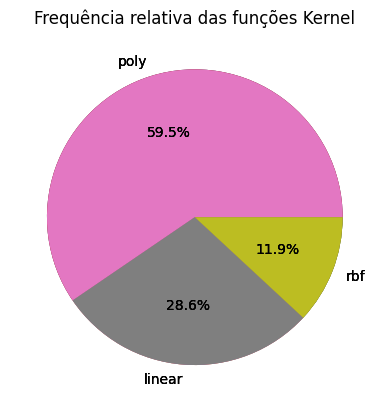

In [45]:
#.1 Qual é o kernel mais utlizado

for file in os.scandir(final_eval_path):
    df = pd.read_csv(file.path)
    kernel_column: pd.Series = df["Kernel Function"]
    counts = kernel_column.value_counts()

    freq = counts.values  # Equivalent to np.array(counts)
    labels = counts.index
    plt.title("Frequência relativa das funções Kernel")
    plt.pie(freq, labels=labels,autopct='%1.1f%%')


In [46]:
import os
import pandas as pd
from collections import defaultdict


# Paths para os ficheiros de avaliação relevantes
final_eval_path= Path(base_dir/"train_and_evaluate_dir")

# 1. Configuração inicial
kernels_e_datasets = defaultdict(set)
coluna_dataset = "Dataset"  # Nome da coluna dentro dos teus ficheiros CSV

# 2. Processamento dos ficheiros (O teu código original)
for file in os.scandir(final_eval_path):
    if file.is_file() and file.name.endswith('.csv'):
        df = pd.read_csv(file.path)

        if coluna_dataset in df.columns and "Kernel Function" in df.columns:
            for _, row in df[[coluna_dataset, "Kernel Function"]].dropna().iterrows():
                kernel = str(row["Kernel Function"]).strip()
                dataset_real = str(row[coluna_dataset]).strip()
                kernels_e_datasets[kernel].add(dataset_real)

# --- NOVO: Transformação para CSV ---

# 3. Converter o dicionário para uma estrutura de tabela (lista de dicionários)
dados_para_exportar = []
for kernel, datasets in kernels_e_datasets.items():
    dados_para_exportar.append({
        "Kernel": kernel,
        "Datasets_Reais": ", ".join(sorted(datasets)),
        "Quantidade": len(datasets)
    })

# 4. Criar o DataFrame e exportar para CSV
df_final = pd.DataFrame(dados_para_exportar)
df_final.to_csv("analise_datasets_por_kernel.csv", index=False, encoding='utf-8-sig')

print("Análise concluída! O ficheiro 'analise_datasets_por_kernel.csv' foi gerado.")

Análise concluída! O ficheiro 'analise_datasets_por_kernel.csv' foi gerado.


In [49]:
import pandas as pd

# 1. Carregar o ficheiro (usando o separador ',' que é mais comum para CSV)
df = pd.read_csv('winner_by_dataset.csv', sep=',')

# 2. LIMPEZA DE COLUNAS (O passo mais importante)
# Remove espaços no início e fim de cada nome de coluna
df.columns = df.columns.str.strip()

# 3. Definição das colunas após a limpeza
# Agora 'best_model_Balanced Accuracy' já não terá o espaço no fim
col_vencedor = 'best_model_Balanced_Accuracy'
col_dataset = 'Dataset'

# 4. Agrupar os datasets por cada modelo
# Usamos o .astype(str) para garantir que nomes de ficheiros são tratados como texto
agrupamento = df.groupby(col_vencedor)[col_dataset].apply(lambda x: ', '.join(x.astype(str))).reset_index()

# 5. Renomear para o relatório final
agrupamento.columns = ['Modelo_Vencedor', 'Lista_de_Datasets']

# 6. Adicionar a contagem de vitórias
vitorias = df[col_vencedor].value_counts().reset_index()
vitorias.columns = ['Modelo_Vencedor', 'Total_Vitorias']

# 7. Juntar tudo num DataFrame final
df_final = pd.merge(agrupamento, vitorias, on='Modelo_Vencedor')

# 8. Exportar para um novo ficheiro CSV
df_final.to_csv('relatorio_vencedores_agrupado.csv', index=False, sep=';', encoding='utf-8-sig')

print("Ficheiro 'relatorio_vencedores_agrupado.csv' gerado com sucesso!")
print(df_final)

Ficheiro 'relatorio_vencedores_agrupado.csv' gerado com sucesso!
    Modelo_Vencedor                                  Lista_de_Datasets  \
0      SVM_STANDARD  dataset_13_breast-cancer.csv, dataset_164_mole...   
1    SVM_modified_3  dataset_334_monks-problems-2.csv, dataset_448_...   
2  SVM_modified_3.1  dataset_25_colic.csv, dataset_27_colic.csv, da...   

   Total_Vitorias  
0              19  
1               4  
2              19  


In [55]:
import pandas as pd
import os
from collections import defaultdict

# --- CONFIGURAÇÃO DE CAMINHOS ---
ficheiro_vencedores = "relatorio_vencedores_agrupado.csv"
ficheiro_kernels_datasets = "analise_datasets_por_kernel.csv" # Renamed for clarity

# 1. MAPEAMENTO: Datasets por Kernel (Carregar do ficheiro gerado 'analise_datasets_por_kernel.csv')
datasets_por_kernel = defaultdict(set)
df_kernels_datasets = pd.read_csv(ficheiro_kernels_datasets)

# Populate datasets_por_kernel from the loaded DataFrame
for index, row in df_kernels_datasets.iterrows():
    kernel = row["Kernel"].strip()
    datasets_str = row["Datasets_Reais"]
    if pd.notna(datasets_str) and datasets_str:
        datasets_list = [ds.strip() for ds in datasets_str.split(',')]
        for ds in datasets_list:
            datasets_por_kernel[kernel].add(ds)

# 2. MAPEAMENTO: Modelo Vencedor por Dataset (Lógica do ficheiro consolidado 'relatorio_vencedores_agrupado.csv')
df_vencedores = pd.read_csv(ficheiro_vencedores, sep=';')
df_vencedores.columns = df_vencedores.columns.str.strip()

# Criar um dicionário para consulta rápida: { 'nome_dataset': 'modelo_vencedor' }
mapa_vencedores = {}
for index, row in df_vencedores.iterrows():
    model_winner = row['Modelo_Vencedor']
    datasets_str = row['Lista_de_Datasets']
    if pd.notna(datasets_str) and datasets_str:
        datasets_list = [ds.strip() for ds in datasets_str.split(', ')] # Split by ', ' to handle spaces
        for ds in datasets_list:
            mapa_vencedores[ds] = model_winner

# 3. CRUZAMENTO DE DADOS
relatorio_comparativo = []

for kernel, lista_datasets in datasets_por_kernel.items():
    for ds in lista_datasets:
        # Verificamos quem ganhou neste dataset específico
        vencedor = mapa_vencedores.get(ds, "Não encontrado")

        relatorio_comparativo.append({
            "Kernel_Utilizado": kernel,
            "Dataset": ds,
            "Modelo_Vencedor": vencedor
        })

# 4. CRIAR DATAFRAME E EXPORTAR
df_final = pd.DataFrame(relatorio_comparativo)

# Ordenar para facilitar a leitura (Agrupar por Kernel)
df_final = df_final.sort_values(by=["Kernel_Utilizado", "Modelo_Vencedor"])

# Salvar o resultado
df_final.to_csv("comparativo_kernel_vs_vencedor.csv", index=False, sep=';', encoding='utf-8-sig')

print("Análise comparativa gerada com sucesso!")
print(df_final.head(10))

Análise comparativa gerada com sucesso!
   Kernel_Utilizado                                      Dataset  \
5            linear                 dataset_13_breast-cancer.csv   
8            linear                        dataset_336_SPECT.csv   
9            linear  dataset_164_molecular-biology_promoters.csv   
10           linear                   dataset_50_tic-tac-toe.csv   
0            linear             dataset_334_monks-problems-2.csv   
6            linear                          dataset_56_vote.csv   
7            linear                     dataset_463_backache.csv   
11           linear          dataset_448_analcatdata_boxing1.csv   
1            linear             dataset_335_monks-problems-3.csv   
2            linear                      dataset_738_pharynx.csv   

     Modelo_Vencedor  
5       SVM_STANDARD  
8       SVM_STANDARD  
9       SVM_STANDARD  
10      SVM_STANDARD  
0     SVM_modified_3  
6     SVM_modified_3  
7     SVM_modified_3  
11    SVM_modified_3  
1   

In [57]:
import pandas as pd

# 1. Carregar o relatório de cruzamento (gerado no passo anterior)
ficheiro_cruzamento = "comparativo_kernel_vs_vencedor.csv" # Corrigido o nome do ficheiro
df = pd.read_csv(ficheiro_cruzamento, sep=';')

# 2. DEFINIR AS TUAS EXPECTATIVAS (Ajusta os nomes dos modelos conforme o teu CSV)
# Exemplo: { 'nome_do_kernel': 'modelo_esperado' }
expectativas = {
    'rbf': 'SVM_STANDARD',
    'poly': 'SVM_modified_3' # Ajusta para o nome exato do teu modelo vencedor
}

def calcular_erro(row):
    kernel = str(row['Kernel_Utilizado']).strip().lower() # Corrigido o nome da coluna
    vencedor = str(row['Modelo_Vencedor']).strip() # Corrigido o nome da coluna

    # Se o kernel estiver nas nossas expectativas, verificamos se o vencedor bate certo
    if kernel in expectativas:
        modelo_esperado = expectativas[kernel]
        # Retorna 0 se acertou (erro zero), 1 se errou (erro total)
        return 0 if vencedor == modelo_esperado else 1
    return None # Para kernels que não queremos analisar agora

# 3. Aplicar o cálculo
df['Erro'] = df.apply(calcular_erro, axis=1)

# Remover linhas onde o kernel não faz parte da nossa análise de hipótese
df_analise = df.dropna(subset=['Erro'])

# 4. CÁLCULO DA PERCENTAGEM
total_testes = len(df_analise)
total_erros = df_analise['Erro'].sum()

if total_testes > 0:
    percentagem_erro = (total_erros / total_testes) * 100
    precisao_da_hipotese = 100 - percentagem_erro

    print(f"--- RESULTADOS DA ANÁLISE ---")
    print(f"Total de Datasets analisados: {total_testes}")
    print(f"Total de divergências (erros): {total_erros}")
    print(f"Percentagem de Erro: {percentagem_erro:.2f}%")
    print(f"Confirmação da Hipótese: {precisao_da_hipotese:.2f}%")
else:
    print("Não foram encontrados dados suficientes para os kernels definidos.")

# Opcional: Guardar os erros para veres onde o modelo falhou
df_analise[df_analise['Erro'] == 1].to_csv("detalhe_dos_erros.csv", index=False, sep=';')

--- RESULTADOS DA ANÁLISE ---
Total de Datasets analisados: 30
Total de divergências (erros): 28.0
Percentagem de Erro: 93.33%
Confirmação da Hipótese: 6.67%


# NOTA

Removi o dataset_720 porque o MODIFIED_31_1 não o processou por alguma razão. O dataset foi removido dos ficheiros eval gerados para testar a pipeline de avaliação.

No MODIFIED_31_1. o dataset_3 foi guardado 2 vezes: uma vez com +/- e outra com a notação ±. Temos de ver o que é que pode estar a causar isto.

# Mean Performance Friedman + correção Bonferroni-Dunn


In [ ]:
#2. Quantos tiveram uma balance accuracy abaixo de 0.5?

from sources import eval_analysis

eval_analysis.__main__()

# Per dataset / winner for the same kernel.

best_kernel() retorna sempre o melhor dataset de acordo as metafeatures e sem intervenção do modelo.
Precisamos de determinar qual foi o modelo que teve a melhor resposta para cada métrica e para cada dataset.



In [ ]:
from sources import eval_analysis
eval_analysis.winner_by_dataset()